Setup and Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os


base_path = '/content/drive/MyDrive/ColabNotebooks/608Project/InputFiles'
print(os.listdir(base_path))

['processed.cleveland.data', 'pmdata.zip', 'WESAD.zip']


In [ ]:
import zipfile

# unzip PMData
with zipfile.ZipFile(f'{base_path}/pmdata.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/pmdata')

# unzip WESAD
with zipfile.ZipFile(f'{base_path}/WESAD.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/wesad')

In [ ]:
import os

print(os.listdir('/content/pmdata')[:5])
print(os.listdir('/content/wesad')[:5])

['p02', 'p10', 'participant-overview.xlsx', 'p09', 'p12']
['WESAD']


Loading the Heart Dataset

In [ ]:
import pandas as pd

columns = [
'age','sex','cp','trestbps','chol','fbs',
'restecg','thalach','exang','oldpeak',
'slope','ca','thal','target'
]

df_heart = pd.read_csv(
    f'{base_path}/processed.cleveland.data',
    names=columns
)

df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Replacing Missing Values

In [ ]:
df_heart.replace('?', pd.NA, inplace=True)

Converting to Numeric

In [ ]:
df_heart = df_heart.apply(pd.to_numeric)

Checking for Missing Values

In [ ]:
df_heart.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Filling Missing Values

In [ ]:
df_heart.fillna(df_heart.median(), inplace=True)

Converting Target to Binary

In [ ]:
df_heart['target'] = df_heart['target'].apply(lambda x: 1 if x > 0 else 0)

Adding Metadata

In [ ]:
df_heart['source_dataset'] = 'uci_heart'
df_heart['record_id'] = range(1, len(df_heart)+1)

In [ ]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_dataset,record_id
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,uci_heart,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,uci_heart,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,uci_heart,3
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,uci_heart,4
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,uci_heart,5


Saving the Cleaned Dataset

In [ ]:
df_heart.to_csv('/content/uci_heart_clean.csv', index=False)

PM Data

In [ ]:
import os

print(os.listdir('/content/pmdata'))

['p02', 'p10', 'participant-overview.xlsx', 'p09', 'p12', 'p13', 'p15', 'p07', 'p01', 'p16', 'p08', 'p05', 'p11', 'p04', 'p14', 'p06', 'p03']


In [ ]:
print(os.listdir('/content/pmdata/p01'))

['food-images', 'pmsys', 'fitbit', 'googledocs']


Inspecting Fit bit Files Inside p01

In [ ]:
for root, dirs, files in os.walk('/content/pmdata/p01/fitbit'):
    print("FOLDER:", root)
    print("FILES:", files)
    print("-" * 50)

FOLDER: /content/pmdata/p01/fitbit
FILES: ['sleep.json', 'moderately_active_minutes.json', 'resting_heart_rate.json', 'calories.json', 'sedentary_minutes.json', 'sleep_score.csv', 'heart_rate.json', 'distance.json', 'exercise.json', 'very_active_minutes.json', 'time_in_heart_rate_zones.json', 'lightly_active_minutes.json', 'steps.json']
--------------------------------------------------


In [ ]:
import pandas as pd
import json

resting_hr_path = '/content/pmdata/p01/fitbit/resting_heart_rate.json'

df_resting_hr = pd.read_json(resting_hr_path)
df_resting_hr.head()

,dateTime,value
0,2019-11-01,"{'date': '11/01/19', 'value': 53.7410736083984..."
1,2019-11-02,"{'date': '11/02/19', 'value': 52.8814973831176..."
2,2019-11-03,"{'date': '11/03/19', 'value': 53.2220239639282..."
3,2019-11-04,"{'date': '11/04/19', 'value': 54.3111410140991..."
4,2019-11-05,"{'date': '11/05/19', 'value': 52.2591104507446..."


In [ ]:
df_resting_hr['value'] = df_resting_hr['value'].apply(lambda x: x['value'])

In [ ]:
df_resting_hr['value'] = pd.to_numeric(df_resting_hr['value'])

In [ ]:
df_resting_hr.head()

,dateTime,value
0,2019-11-01,53.741074
1,2019-11-02,52.881497
2,2019-11-03,53.222024
3,2019-11-04,54.311141
4,2019-11-05,52.259110


In [ ]:
avg_resting_hr = df_resting_hr['value'].mean()
avg_resting_hr

np.float64(52.276793567757856)

In [ ]:
heart_rate_path = '/content/pmdata/p01/fitbit/heart_rate.json'

df_heart_rate_pm = pd.read_json(heart_rate_path)
df_heart_rate_pm.head()

,dateTime,value
0,2019-11-01 00:00:05,"{'bpm': 54, 'confidence': 3}"
1,2019-11-01 00:00:10,"{'bpm': 52, 'confidence': 3}"
2,2019-11-01 00:00:20,"{'bpm': 51, 'confidence': 3}"
3,2019-11-01 00:00:25,"{'bpm': 52, 'confidence': 3}"
4,2019-11-01 00:00:30,"{'bpm': 51, 'confidence': 3}"


In [ ]:
df_heart_rate_pm['bpm'] = df_heart_rate_pm['value'].apply(
    lambda x: x.get('bpm') if isinstance(x, dict) else None
)

df_heart_rate_pm['bpm'] = pd.to_numeric(df_heart_rate_pm['bpm'], errors='coerce')

avg_hr = df_heart_rate_pm['bpm'].mean()
avg_hr

np.float64(64.46286880270029)

In [ ]:
steps_path = '/content/pmdata/p01/fitbit/steps.json'

df_steps = pd.read_json(steps_path)

df_steps['value'] = pd.to_numeric(df_steps['value'], errors='coerce')

avg_steps = df_steps['value'].mean()
avg_steps

np.float64(8.767652488621616)

In [ ]:
calories_path = '/content/pmdata/p01/fitbit/calories.json'

df_calories = pd.read_json(calories_path)
df_calories.head()

,dateTime,value
0,2019-11-01 00:00:00,1.39
1,2019-11-01 00:01:00,1.39
2,2019-11-01 00:02:00,1.39
3,2019-11-01 00:03:00,1.39
4,2019-11-01 00:04:00,1.39


In [ ]:
df_calories['value'] = pd.to_numeric(df_calories['value'], errors='coerce')

avg_calories = df_calories['value'].mean()
avg_calories

np.float64(2.5052866867690065)

In [ ]:
sleep_score_path = '/content/pmdata/p01/fitbit/sleep_score.csv'

df_sleep_score = pd.read_csv(sleep_score_path)
df_sleep_score.head()

,timestamp,sleep_log_entry_id,overall_score,composition_score,revitalization_score,duration_score,deep_sleep_in_minutes,resting_heart_rate,restlessness
0,2019-11-01T06:29:30Z,24472394143,76,18,20,38,27,53,0.053635
1,2019-11-02T07:19:30Z,24486013387,79,20,22,37,36,53,0.078978
2,2019-11-03T07:34:30Z,24497341340,71,16,17,38,38,52,0.093491
3,2019-11-04T06:35:00Z,24507914069,68,15,15,38,37,53,0.064851
4,2019-11-05T06:25:00Z,24521896102,73,15,22,36,26,54,0.093185


In [ ]:
avg_sleep_score = df_sleep_score['overall_score'].mean()
avg_sleep_score

np.float64(71.63333333333334)

In [ ]:
participant_summary = {
    'participant_id': 'p01',
    'avg_resting_hr': avg_resting_hr,
    'avg_hr': avg_hr,
    'avg_steps': avg_steps,
    'avg_calories': avg_calories,
    'avg_sleep_score': avg_sleep_score,
    'source_dataset': 'pmdata'
}

pmdata_p01_summary = pd.DataFrame([participant_summary])
pmdata_p01_summary

,participant_id,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,source_dataset
0,p01,52.276794,64.462869,8.767652,2.505287,71.633333,pmdata


In [ ]:
import os
import pandas as pd

pmdata_rows = []

participant_folders = sorted([
    f for f in os.listdir('/content/pmdata')
    if f.startswith('p') and os.path.isdir(f'/content/pmdata/{f}')
])

for participant in participant_folders:
    fitbit_path = f'/content/pmdata/{participant}/fitbit'

    try:
        df_resting_hr = pd.read_json(f'{fitbit_path}/resting_heart_rate.json')
        df_resting_hr['value'] = df_resting_hr['value'].apply(
            lambda x: x['value'] if isinstance(x, dict) else x
        )
        df_resting_hr['value'] = pd.to_numeric(df_resting_hr['value'], errors='coerce')
        avg_resting_hr = df_resting_hr['value'].mean()
    except:
        avg_resting_hr = None

    try:
        df_heart_rate_pm = pd.read_json(f'{fitbit_path}/heart_rate.json')
        df_heart_rate_pm['bpm'] = df_heart_rate_pm['value'].apply(
            lambda x: x.get('bpm') if isinstance(x, dict) else None
        )
        df_heart_rate_pm['bpm'] = pd.to_numeric(df_heart_rate_pm['bpm'], errors='coerce')
        avg_hr = df_heart_rate_pm['bpm'].mean()
    except:
        avg_hr = None

    try:
        df_steps = pd.read_json(f'{fitbit_path}/steps.json')
        df_steps['value'] = pd.to_numeric(df_steps['value'], errors='coerce')
        avg_steps = df_steps['value'].mean()
    except:
        avg_steps = None

    try:
        df_calories = pd.read_json(f'{fitbit_path}/calories.json')
        df_calories['value'] = pd.to_numeric(df_calories['value'], errors='coerce')
        avg_calories = df_calories['value'].mean()
    except:
        avg_calories = None

    try:
        df_sleep_score = pd.read_csv(f'{fitbit_path}/sleep_score.csv')
        avg_sleep_score = df_sleep_score['overall_score'].mean()
    except:
        avg_sleep_score = None

    pmdata_rows.append({
        'participant_id': participant,
        'avg_resting_hr': avg_resting_hr,
        'avg_hr': avg_hr,
        'avg_steps': avg_steps,
        'avg_calories': avg_calories,
        'avg_sleep_score': avg_sleep_score,
        'source_dataset': 'pmdata'
    })

pmdata_clean = pd.DataFrame(pmdata_rows)
pmdata_clean

,participant_id,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,source_dataset
0,p01,52.276794,64.462869,8.767652,2.505287,71.633333,pmdata
1,p02,46.184370,64.735687,21.958379,2.390532,71.376812,pmdata
2,p03,37.504385,67.752503,12.324837,1.744911,75.364865,pmdata
3,p04,70.355010,81.193347,17.541980,1.411006,78.678571,pmdata
4,p05,58.202185,74.696195,14.745188,2.350958,79.931624,pmdata
5,p06,49.978676,63.863499,17.901766,2.482430,78.795918,pmdata
6,p07,56.408880,76.432339,21.484748,2.216104,79.171429,pmdata
7,p08,53.665221,75.497350,22.434232,2.647340,74.333333,pmdata
8,p09,59.233310,69.435437,10.166798,1.897324,74.303030,pmdata
9,p10,50.522412,81.880118,17.942660,1.565991,78.040816,pmdata


In [ ]:
pmdata_clean.to_csv('/content/pmdata_clean.csv', index=False)

In [ ]:
os.listdir('/content')

['.config',
 'pmdata_clean.csv',
 'uci_heart_clean.csv',
 'wesad',
 'drive',
 'pmdata',
 'sample_data']

WESAD Dataset

In [ ]:
import os

wesad_subjects = sorted([
    f for f in os.listdir('/content/wesad')
    if f.startswith('S') and os.path.isdir(f'/content/wesad/{f}')
])

wesad_subjects

[]

In [ ]:
os.listdir('/content/wesad')

['WESAD']

In [ ]:
os.listdir('/content/wesad/WESAD')[:10]

['S9', 'S8', 'S15', 'wesad_readme.pdf', 'S16', 'S10', 'S14', 'S4', 'S7', 'S13']

In [ ]:
wesad_base = '/content/wesad/WESAD'

In [ ]:
import pickle

with open(f'{wesad_base}/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

data.keys()

dict_keys(['signal', 'label', 'subject'])

Inspecting the sensors

In [ ]:
signal = data['signal']
label = data['label']

print(signal.keys())

dict_keys(['chest', 'wrist'])


In [ ]:
print(signal['wrist'].keys())

dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [ ]:
print(signal['chest'].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


Extracting Features for S2

In [ ]:
import numpy as np
import pandas as pd

wrist = signal['wrist']
chest = signal['chest']

s2_summary = {
    'participant_id': 'S2',
    'eda_mean': np.mean(wrist['EDA']),
    'bvp_mean': np.mean(wrist['BVP']),
    'temp_mean': np.mean(wrist['TEMP']),
    'ecg_mean': np.mean(chest['ECG']),
    'stress_label_mean': np.mean(label),
    'source_dataset': 'wesad'
}

wesad_s2_summary = pd.DataFrame([s2_summary])
wesad_s2_summary

,participant_id,eda_mean,bvp_mean,temp_mean,ecg_mean,stress_label_mean,source_dataset
0,S2,0.391743,-0.000427,34.386945,0.001212,1.21237,wesad


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

wesad_rows = []

wesad_subjects = sorted([
    f for f in os.listdir(wesad_base)
    if f.startswith('S') and os.path.isdir(f'{wesad_base}/{f}')
])

for subject in wesad_subjects:
    try:
        with open(f'{wesad_base}/{subject}/{subject}.pkl', 'rb') as f:
            data = pickle.load(f, encoding='latin1')

        signal = data['signal']
        label = data['label']

        wrist = signal['wrist']
        chest = signal['chest']

        wesad_rows.append({
            'participant_id': subject,
            'eda_mean': np.mean(wrist['EDA']),
            'bvp_mean': np.mean(wrist['BVP']),
            'temp_mean': np.mean(wrist['TEMP']),
            'ecg_mean': np.mean(chest['ECG']),
            'stress_label_mean': np.mean(label),
            'source_dataset': 'wesad'
        })

    except Exception as e:
        print(f"Error processing {subject}: {e}")

wesad_clean = pd.DataFrame(wesad_rows)
wesad_clean

,participant_id,eda_mean,bvp_mean,temp_mean,ecg_mean,stress_label_mean,source_dataset
0,S10,0.981519,0.000452,33.430048,0.001254,1.429039,wesad
1,S11,3.184846,0.001623,32.836507,0.001054,1.475253,wesad
2,S13,7.093560,0.004261,34.304465,0.001111,1.355788,wesad
3,S14,0.314341,0.011153,32.370234,0.000842,1.414024,wesad
4,S15,0.635140,-0.000190,29.982887,0.001106,1.464774,wesad
5,S16,0.716151,0.001081,30.432433,0.000438,1.382702,wesad
6,S17,1.080372,0.001352,32.706384,0.000965,1.302363,wesad
7,S2,0.391743,-0.000427,34.386945,0.001212,1.212370,wesad
8,S3,1.231475,-0.000089,31.772432,0.000793,1.216850,wesad
9,S4,0.475163,0.005529,32.435563,0.001240,1.190566,wesad


Saving the Cleaned Dataset

In [ ]:
wesad_clean.to_csv('/content/wesad_clean.csv', index=False)

In [ ]:
print("Heart shape:", df_heart.shape)
print("PMData shape:", pmdata_clean.shape)
print("WESAD shape:", wesad_clean.shape)

Heart shape: (303, 16)
PMData shape: (16, 7)
WESAD shape: (15, 7)


In [ ]:
common_columns = [
    'record_id',
    'participant_id',
    'source_dataset',
    'age',
    'sex',
    'resting_bp',
    'chol',
    'max_hr',
    'avg_resting_hr',
    'avg_hr',
    'avg_steps',
    'avg_calories',
    'avg_sleep_score',
    'eda_mean',
    'bvp_mean',
    'temp_mean',
    'ecg_mean',
    'cardio_risk_label',
    'stress_label_mean'
]

Standardizing the Heart Dataset

In [ ]:
heart_standardized = df_heart.copy()

heart_standardized = heart_standardized.rename(columns={
    'trestbps': 'resting_bp',
    'thalach': 'max_hr',
    'target': 'cardio_risk_label'
})

heart_standardized['participant_id'] = heart_standardized['record_id'].apply(lambda x: f'H{x}')

for col in common_columns:
    if col not in heart_standardized.columns:
        heart_standardized[col] = pd.NA

heart_standardized = heart_standardized[common_columns]
heart_standardized.head()

,record_id,participant_id,source_dataset,age,sex,resting_bp,chol,max_hr,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,eda_mean,bvp_mean,temp_mean,ecg_mean,cardio_risk_label,stress_label_mean
0,1,H1,uci_heart,63.0,1.0,145.0,233.0,150.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>
1,2,H2,uci_heart,67.0,1.0,160.0,286.0,108.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
2,3,H3,uci_heart,67.0,1.0,120.0,229.0,129.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>
3,4,H4,uci_heart,37.0,1.0,130.0,250.0,187.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>
4,5,H5,uci_heart,41.0,0.0,130.0,204.0,172.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,<NA>


Standardizing the PMData dataset

In [ ]:
pmdata_standardized = pmdata_clean.copy()

pmdata_standardized['record_id'] = range(1, len(pmdata_standardized) + 1)

for col in common_columns:
    if col not in pmdata_standardized.columns:
        pmdata_standardized[col] = pd.NA

pmdata_standardized = pmdata_standardized[common_columns]
pmdata_standardized.head()

,record_id,participant_id,source_dataset,age,sex,resting_bp,chol,max_hr,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,eda_mean,bvp_mean,temp_mean,ecg_mean,cardio_risk_label,stress_label_mean
0,1,p01,pmdata,<NA>,<NA>,<NA>,<NA>,<NA>,52.276794,64.462869,8.767652,2.505287,71.633333,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2,p02,pmdata,<NA>,<NA>,<NA>,<NA>,<NA>,46.184370,64.735687,21.958379,2.390532,71.376812,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,3,p03,pmdata,<NA>,<NA>,<NA>,<NA>,<NA>,37.504385,67.752503,12.324837,1.744911,75.364865,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,4,p04,pmdata,<NA>,<NA>,<NA>,<NA>,<NA>,70.355010,81.193347,17.541980,1.411006,78.678571,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,5,p05,pmdata,<NA>,<NA>,<NA>,<NA>,<NA>,58.202185,74.696195,14.745188,2.350958,79.931624,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


Standardizing the WESAD Dataset

In [ ]:
wesad_standardized = wesad_clean.copy()

wesad_standardized['record_id'] = range(1, len(wesad_standardized) + 1)

for col in common_columns:
    if col not in wesad_standardized.columns:
        wesad_standardized[col] = pd.NA

wesad_standardized = wesad_standardized[common_columns]
wesad_standardized.head()

,record_id,participant_id,source_dataset,age,sex,resting_bp,chol,max_hr,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,eda_mean,bvp_mean,temp_mean,ecg_mean,cardio_risk_label,stress_label_mean
0,1,S10,wesad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.981519,0.000452,33.430048,0.001254,<NA>,1.429039
1,2,S11,wesad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3.184846,0.001623,32.836507,0.001054,<NA>,1.475253
2,3,S13,wesad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,7.093560,0.004261,34.304465,0.001111,<NA>,1.355788
3,4,S14,wesad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.314341,0.011153,32.370234,0.000842,<NA>,1.414024
4,5,S15,wesad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.635140,-0.000190,29.982887,0.001106,<NA>,1.464774


In [ ]:
pulsepoint_integrated = pd.concat(
    [heart_standardized, pmdata_standardized, wesad_standardized],
    ignore_index=True
)

/tmp/ipykernel_32142/398101007.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pulsepoint_integrated = pd.concat(


In [ ]:
pulsepoint_integrated.shape

(334, 19)

In [ ]:
pulsepoint_integrated['source_dataset'].value_counts()

,count
source_dataset,
uci_heart,303
pmdata,16
wesad,15


In [ ]:
pulsepoint_integrated.head()

,record_id,participant_id,source_dataset,age,sex,resting_bp,chol,max_hr,avg_resting_hr,avg_hr,avg_steps,avg_calories,avg_sleep_score,eda_mean,bvp_mean,temp_mean,ecg_mean,cardio_risk_label,stress_label_mean
0,1,H1,uci_heart,63.0,1.0,145.0,233.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
1,2,H2,uci_heart,67.0,1.0,160.0,286.0,108.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
2,3,H3,uci_heart,67.0,1.0,120.0,229.0,129.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
3,4,H4,uci_heart,37.0,1.0,130.0,250.0,187.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,5,H5,uci_heart,41.0,0.0,130.0,204.0,172.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN


In [ ]:
pulsepoint_integrated.isna().sum()

,0
record_id,0
participant_id,0
source_dataset,0
age,31
sex,31
resting_bp,31
chol,31
max_hr,31
avg_resting_hr,320
avg_hr,318


In [ ]:
pulsepoint_integrated.to_csv('/content/pulsepoint_integrated.csv', index=False)

In [ ]:
import json

pulsepoint_json = pulsepoint_integrated.to_dict(orient='records')

with open('/content/pulsepoint_ingestion_payload.json', 'w') as f:
    json.dump({
        'source': 'pulsepoint_integrated_pipeline',
        'batch_id': 'batch_001',
        'ingestion_type': 'historical_batch',
        'records': pulsepoint_json
    }, f, indent=2, default=str)

In [ ]:
import numpy as np

pulsepoint_integrated = pulsepoint_integrated.replace({np.nan: None})

In [ ]:
import json

with open('pulsepoint_ingestion_payload.json', 'w') as f:
    json.dump(pulsepoint_integrated.to_dict(orient='records'), f)

In [ ]:
import requests
import numpy as np

clean_payload = {
    "batch_id": "pulsepoint_batch_001",
    "records": pulsepoint_integrated.replace({np.nan: None}).to_dict(orient='records')
}

api_url = "https://0tcvnkirlc.execute-api.us-east-1.amazonaws.com/ingest"

response = requests.post(api_url, json=clean_payload)

print(response.status_code)
print(response.text)

200
{"message": "Upload successful", "file": "raw/20260330T190752Z_pulsepoint_batch_001.json"}


In [ ]:
pulsepoint_integrated.to_csv(
    '/content/drive/MyDrive/ColabNotebooks/608Project/pulsepoint_integrated.csv',
    index=False
)

with open('/content/drive/MyDrive/ColabNotebooks/608Project/pulsepoint_ingestion_payload.json', 'w') as f:
    json.dump({
        'source': 'pulsepoint_integrated_pipeline',
        'batch_id': 'batch_001',
        'ingestion_type': 'historical_batch',
        'records': pulsepoint_json
    }, f, indent=2, default=str)

## Phase 2 – PCA, Logistic Regression & Model Export

> **Note:** Cells below continue from the Phase 1 notebook. Run Phase 1 first so `df_heart` is in memory, OR run the standalone re-load cell below.

### 2.1 – Re-load & Prep UCI Heart Data (all 13 features)

In [ ]:
import pandas as pd
import numpy as np
import os

# ── Column names from UCI documentation
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak',
    'slope', 'ca', 'thal', 'target'
]

# Define base_path correctly (ensure no trailing spaces unless intended)
base_path = '/content/drive/MyDrive/ColabNotebooks/608Project/InputFiles'

# Load raw file
try:
    df_heart = pd.read_csv(
        f'{base_path}/processed.cleveland.data',
        names=columns
    )
except FileNotFoundError:
    # Fallback if the first path fails (though it should be correct now)
    df_heart = pd.read_csv(f'{base_path}/processed.cleveland.data', names=columns)

# Clean
df_heart.replace('?', pd.NA, inplace=True)
df_heart = df_heart.apply(pd.to_numeric, errors='coerce')
df_heart.fillna(df_heart.median(numeric_only=True), inplace=True)
df_heart['target'] = df_heart['target'].apply(lambda x: 1 if x > 0 else 0)

print(f"Shape: {df_heart.shape}")
print(f"Label balance - 0: {(df_heart['target']==0).sum()}, 1: {(df_heart['target']==1).sum()}")
df_heart.head()

Shape: (303, 14)
Label balance - 0: 164, 1: 139


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### 2.2 – Feature Selection & Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# All 13 clinical features (no metadata cols)
FEATURE_COLS = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
TARGET_COL   = 'target'

X = df_heart[FEATURE_COLS].values
y = df_heart[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise — CRITICAL: fit only on train, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (242, 13), Test: (61, 13)


### 2.3 – PCA: Reduce to 'Readiness Vector'

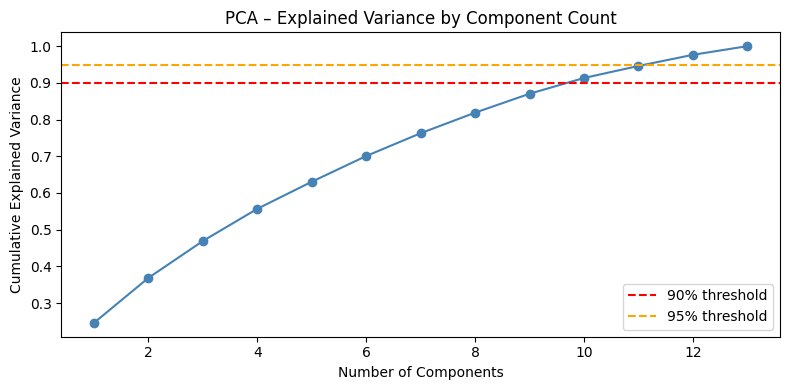

Components for 90% variance: 10
Components for 95% variance: 12


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# First, fit PCA on all components to see explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
plt.axhline(0.90, linestyle='--', color='red', label='90% threshold')
plt.axhline(0.95, linestyle='--', color='orange', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Explained Variance by Component Count')
plt.legend()
plt.tight_layout()
plt.show()

# Identify how many components hit 90% / 95%
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")


PCA reduced features: 13 → 10
Total variance retained: 0.9133


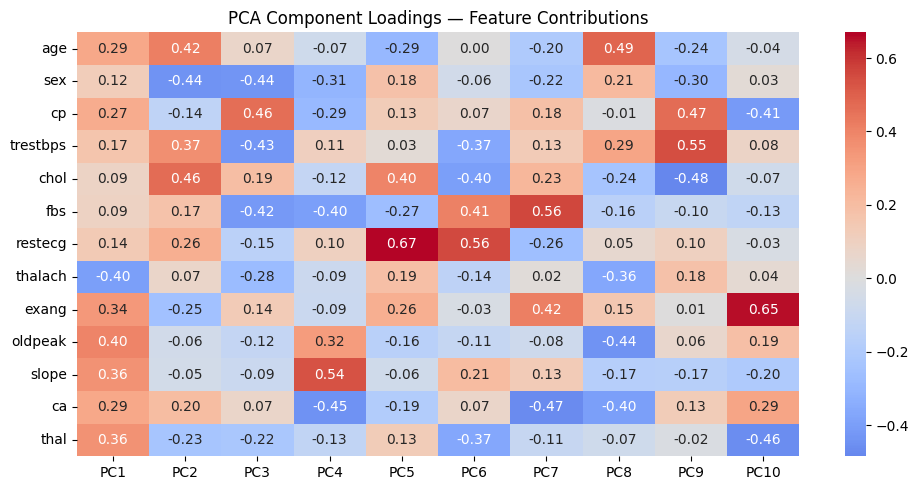

In [ ]:
# Choose N_COMPONENTS based on scree plot above (typically 6-8 for Cleveland)
N_COMPONENTS = n_90  # Use 90% threshold — good balance of compression vs. info

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"PCA reduced features: {X_train_scaled.shape[1]} → {X_train_pca.shape[1]}")
print(f"Total variance retained: {pca.explained_variance_ratio_.sum():.4f}")

# Component loadings heatmap
import seaborn as sns

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

plt.figure(figsize=(10, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('PCA Component Loadings — Feature Contributions')
plt.tight_layout()
plt.show()


### 2.4 – Logistic Regression Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, RocCurveDisplay, f1_score)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_pca, y_train)

y_pred  = lr.predict(X_test_pca)
y_proba = lr.predict_proba(X_test_pca)[:, 1]

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Risk (0)', 'At Risk (1)']))

f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f"F1 Score : {f1:.4f}   (target ≥ 0.75)")
print(f"ROC-AUC  : {auc:.4f}")


Classification Report
              precision    recall  f1-score   support

 No Risk (0)       0.96      0.82      0.89        33
 At Risk (1)       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

F1 Score : 0.8852   (target ≥ 0.75)
ROC-AUC  : 0.9470


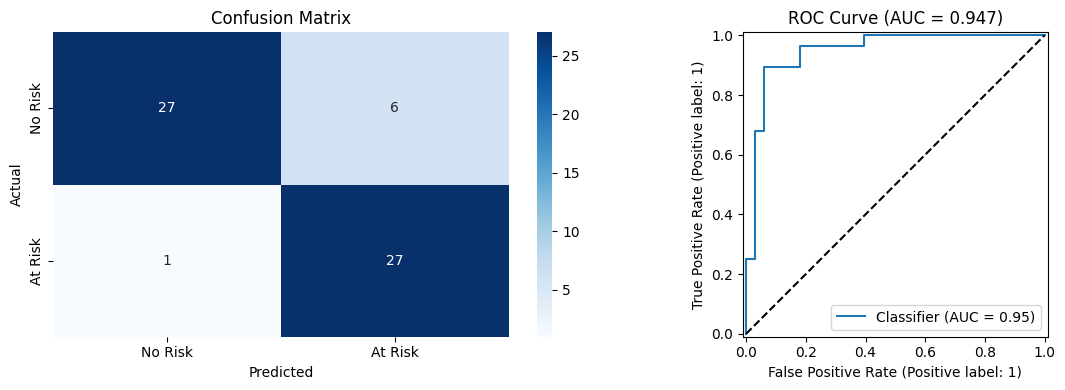

In [ ]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk','At Risk'],
            yticklabels=['No Risk','At Risk'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f'ROC Curve (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')

plt.tight_layout()
plt.show()


### 2.5 – Optional: Cross-Validated Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
grid.fit(X_train_pca, y_train)

print(f"Best params : {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

# Re-evaluate best model on held-out test set
best_lr = grid.best_estimator_
y_pred_best  = best_lr.predict(X_test_pca)
y_proba_best = best_lr.predict_proba(X_test_pca)[:, 1]
print("\nTest set results with best model:")
print(classification_report(y_test, y_pred_best, target_names=['No Risk (0)', 'At Risk (1)']))
print(f"F1 : {f1_score(y_test, y_pred_best):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_best):.4f}")

# Use best model going forward
lr = best_lr


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params : {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1  : 0.8015

Test set results with best model:
              precision    recall  f1-score   support

 No Risk (0)       0.96      0.82      0.89        33
 At Risk (1)       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61

F1 : 0.8852
AUC: 0.9470


### 2.6 – Save Model Artifacts (scaler + pca + model)

In [ ]:
import joblib, os, json
import numpy as np

ARTIFACT_DIR = './model_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(scaler, f'{ARTIFACT_DIR}/scaler.pkl')
joblib.dump(pca,    f'{ARTIFACT_DIR}/pca.pkl')
joblib.dump(lr,     f'{ARTIFACT_DIR}/logistic_model.pkl')

# Determine which predictions to use
_y_pred  = y_pred_best  if 'y_pred_best'  in dir() else y_pred
_y_proba = y_proba_best if 'y_proba_best' in dir() else y_proba

metadata = {
    'feature_cols':          FEATURE_COLS,
    'n_pca_components':      int(N_COMPONENTS),          # cast to native int
    'pca_variance_retained': float(pca.explained_variance_ratio_.sum()),
    'label_map':             {'0': 'No Cardiovascular Risk', '1': 'Cardiovascular Risk Detected'},
    'model_type':            'LogisticRegression + PCA',
    'trained_on':            'UCI Cleveland Heart Disease Dataset (n=303)',
    'f1_score':              float(f1_score(y_test, _y_pred)),
    'roc_auc':               float(roc_auc_score(y_test, _y_proba))
}

with open(f'{ARTIFACT_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved artifacts:")
for f in os.listdir(ARTIFACT_DIR):
    print(f"  {ARTIFACT_DIR}/{f}")


Saved artifacts:
  ./model_artifacts/scaler.pkl
  ./model_artifacts/logistic_model.pkl
  ./model_artifacts/pca.pkl
  ./model_artifacts/model_metadata.json


In [ ]:
import shutil, os

drive_artifact_dir = '/content/drive/MyDrive/ColabNotebooks/608Project/model_artifacts'
os.makedirs(drive_artifact_dir, exist_ok=True)

for f in os.listdir('./model_artifacts'):
    shutil.copy(f'./model_artifacts/{f}', f'{drive_artifact_dir}/{f}')
    print(f'Copied: {f}')

Copied: scaler.pkl
Copied: logistic_model.pkl
Copied: pca.pkl
Copied: model_metadata.json


In [ ]:
import os
os.environ['AWS_ACCESS_KEY_ID']     = 'YOUR_ACCESS_KEY'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'YOUR_SECRET_KEY'
os.environ['AWS_SESSION_TOKEN']     = 'YOUR_SESSION_TOKEN'
os.environ['AWS_DEFAULT_REGION']    = 'us-east-1'

In [ ]:
import boto3
sts = boto3.client('sts')
print(sts.get_caller_identity())

{'UserId': 'AROA3P7PHKKQZWD4P56JF:user4856665=assangh@ucalgary.ca', 'Account': '790238810785', 'Arn': 'arn:aws:sts::790238810785:assumed-role/voclabs/user4856665=assangh@ucalgary.ca', 'ResponseMetadata': {'RequestId': 'e1e63411-5aa1-4ca5-8a23-47b9304561f0', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amzn-requestid': 'e1e63411-5aa1-4ca5-8a23-47b9304561f0', 'x-amz-sts-extended-request-id': 'MTp1cy1lYXN0LTE6UzoxNzc0ODk4MDQwOTEzOlI6Z3NQeHBZOE0=', 'content-type': 'text/xml', 'content-length': '476', 'date': 'Mon, 30 Mar 2026 19:14:00 GMT'}, 'RetryAttempts': 0}}


### 2.7 – Upload Model Artifacts to S3 (Results Zone)

In [ ]:
import boto3

s3 = boto3.client('s3')

BUCKET = 'pulsepoint-raw-zone-akaljotmena'

s3.create_bucket(Bucket=BUCKET)
print(f'Bucket created: {BUCKET}')


Bucket created: pulsepoint-raw-zone-akaljotmena


In [ ]:
RESULTS_PREFIX = 'model_artifacts/'

for fname in os.listdir('./model_artifacts'):
    local_path = f'./model_artifacts/{fname}'
    s3_key     = f'{RESULTS_PREFIX}{fname}'
    s3.upload_file(local_path, BUCKET, s3_key)
    print(f'Uploaded: s3://{BUCKET}/{s3_key}')

Uploaded: s3://pulsepoint-raw-zone-akaljotmena/model_artifacts/scaler.pkl
Uploaded: s3://pulsepoint-raw-zone-akaljotmena/model_artifacts/logistic_model.pkl
Uploaded: s3://pulsepoint-raw-zone-akaljotmena/model_artifacts/pca.pkl
Uploaded: s3://pulsepoint-raw-zone-akaljotmena/model_artifacts/model_metadata.json


In [ ]:
response = s3.list_objects_v2(Bucket=BUCKET, Prefix='model_artifacts/')
for obj in response['Contents']:
    print(obj['Key'])

model_artifacts/logistic_model.pkl
model_artifacts/model_metadata.json
model_artifacts/pca.pkl
model_artifacts/scaler.pkl


In [ ]:
print(boto3.client('sts').get_caller_identity()['Account'])

790238810785
